In [50]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Load the data

In [59]:
# Read in results and saved mse table
saved_data = pd.read_pickle("../../data/results/all_results_v1.pkl")
mse_logs = pd.read_csv("../../data/results/mse_results.csv")

# Read in ACLED data
acled_data = pd.read_csv("../../data/ACLED/intensity_change_monthly_country.csv")

# Only relevant for figure 2
country_to_country_all = pd.read_csv('../../data/GDELT/saved_data/country_to_country_all.csv')
countries_codes = pd.read_csv('../../data/auxilary_data/countries_iso_fips_capitals.csv')
country_coordinates = pd.read_csv("https://gist.githubusercontent.com/tadast/8827699/raw/61b2107766d6fd51e2bd02d9f78f6be081340efc/countries_codes_and_coordinates.csv")

# For figure 3
combined_data = pd.read_csv(f"../../data/Test_training/afghanistan.csv")

### Figure 1

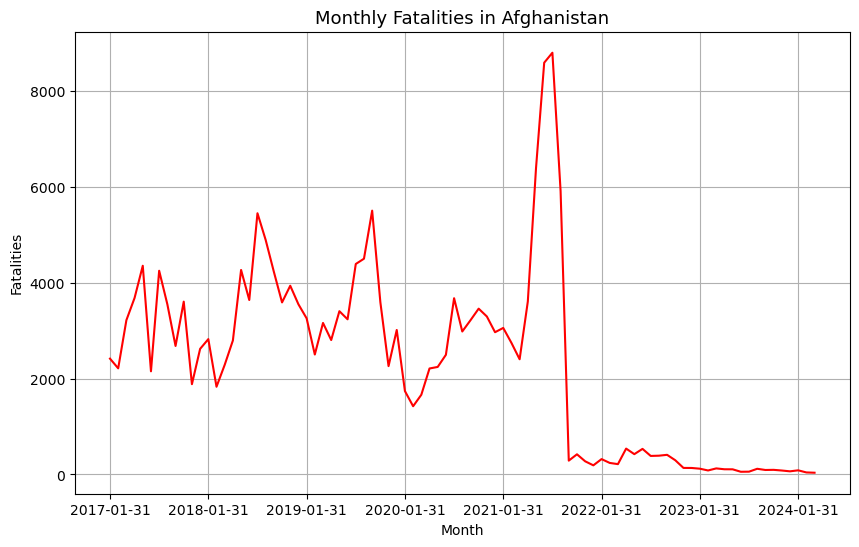

In [73]:
x = acled_data[acled_data["country"] == "Afghanistan"]["event_date"]
plt.figure(figsize=(10, 6))
plt.plot(x, acled_data[acled_data["country"] == "Afghanistan"]["fatalities"], color="red")
plt.xlabel('Month')
plt.xticks(x[::12])
plt.ylabel('Fatalities')
plt.title('Monthly Fatalities in Afghanistan', size=13)
plt.grid(True)
plt.savefig("Paper figures/Figure 1.png")
plt.show()

### Figure 2

Preprocess data in order to plot:

In [60]:
# remove quotes from both sides of all strings in the dataframe
country_coordinates = country_coordinates.map(lambda x: x.replace('"', "").strip())

countries_codes['GDELT_name'] = countries_codes['GDELT_name'].str.strip()
gdelt_name_to_ISO_dict = dict(zip(countries_codes['GDELT_name'], countries_codes['ISO_alpha3']))
combined_f = country_to_country_all.drop(columns = ["Date", "Unnamed: 2"])
copied_df = combined_f.groupby(["Target country"]).mean().sort_values(by = "Target country")

# set the entry of afghanistan in the afghanistan column to 0
for country in copied_df.columns:
    copied_df.loc[country, country] = None
copied_df["average"] = copied_df.mean(axis=1)

copied_df["ISO"] = copied_df.index.map(gdelt_name_to_ISO_dict)
cp_reset = copied_df.reset_index()

Make auxiliary functions to derive coordinates and make map:

In [67]:
def get_coordinates(alpha_3):
    try:
        return country_coordinates[country_coordinates['Alpha-3 code'] == alpha_3][['Latitude (average)', 'Longitude (average)']].values[0]
    except:
        return [None, None]

def plot_coverage_lines_country(cp_reset, source_country):

    fig = go.Figure()

    # don't display the legend
    fig.update_layout(showlegend=False)

    fig.update_layout(
        # template='plotly_dark',
        width=1200,
        height=600,
        coloraxis_colorbar=dict(title=f'%'),
        margin={"r":0,"t":70,"l":0,"b":10},
        title={
        'text': f'<b>Coverage of Afghanistan as present in the GDELT database</b>',
        'y':0.93,  # Adjust the vertical position of the title
        'x':0.5,  # Center the title horizontally
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 18}},  # Adjust font size as needed,
    )

    lines = []

    source_country_coords = get_coordinates(gdelt_name_to_ISO_dict[source_country])

    for i, target_country in enumerate(cp_reset['Target country']):
        if target_country != source_country:
            intensity = 1.5 * float(cp_reset[cp_reset["Target country"] == target_country][source_country].iloc[0])

            try:
                target_country_coords = get_coordinates(gdelt_name_to_ISO_dict[target_country])
            except:
                pass

            if target_country_coords[0]:
                try:
                    lines.append(
                        go.Scattergeo(
                            lon = [source_country_coords[1], target_country_coords[1]],
                            lat = [source_country_coords[0], target_country_coords[0]],
                            mode = 'lines',
                            line = dict(width = intensity, color = 'black'),
                            opacity = 0.2,
                        )
                    )
                except:
                    pass
    # Add lines to the figure
    for i, line in enumerate(lines):
        fig.add_trace(line)

    fig.write_image("Paper figures/Figure 2.png", width=1200, height=600, scale=10)

    fig.show()

In [68]:
plot_coverage_lines_country(cp_reset, "Afghanistan")

### Figure 3

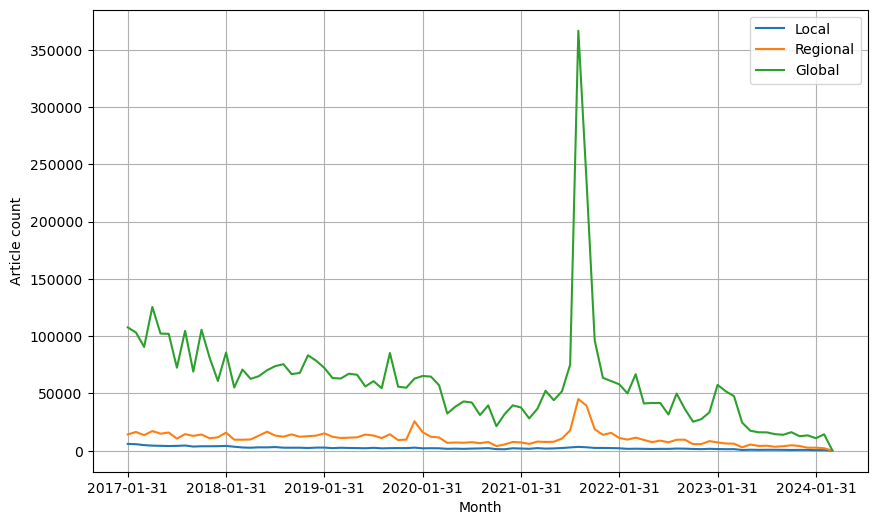

In [74]:
plt.figure(figsize=(10, 6))
for kind in ["Local", "Regional", "International"]:
    data = combined_data[combined_data["News_kind"] == kind]
    plt.plot(data["Month"], data["Article Count"])
plt.xlabel('Month')
plt.ylabel('Article count')
# plt.title('Article count over time')
plt.xticks(data["Month"][::12])  # Ensure all months are shown on x-axis
plt.legend(["Local", "Regional", "Global"])
plt.grid(True)
plt.show()

### Figure 4

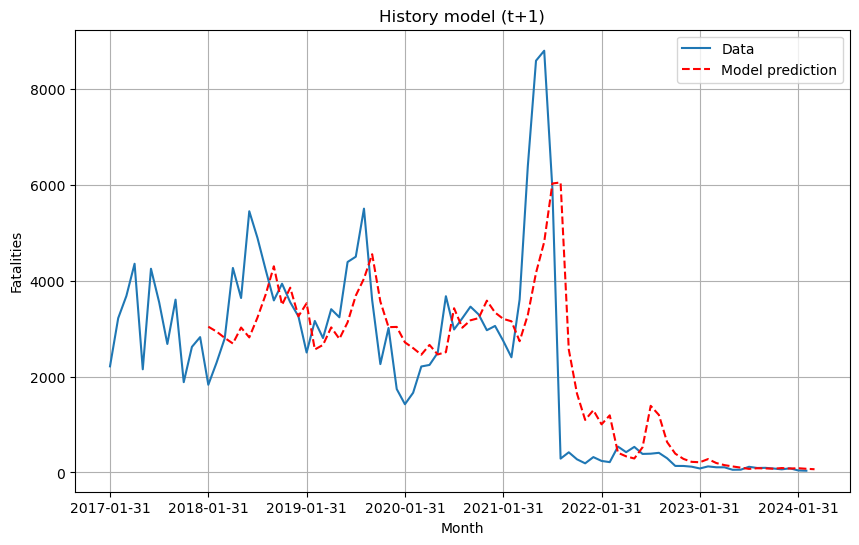

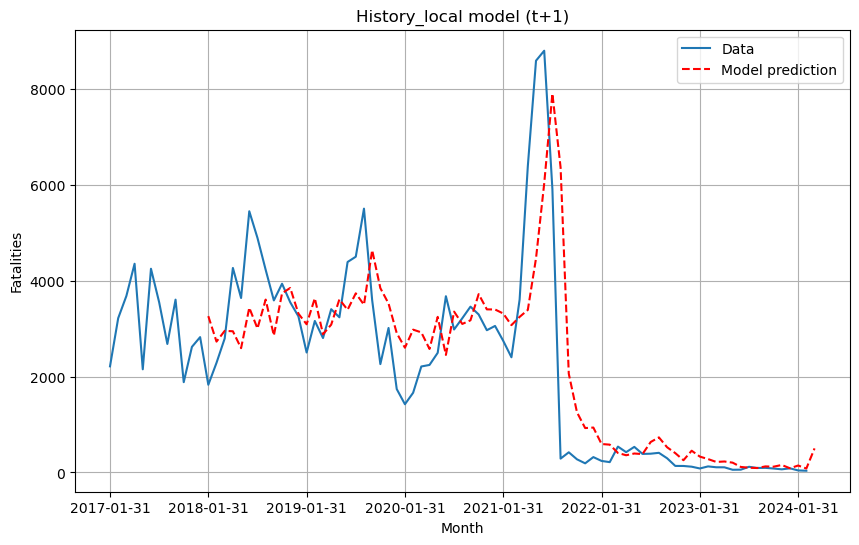

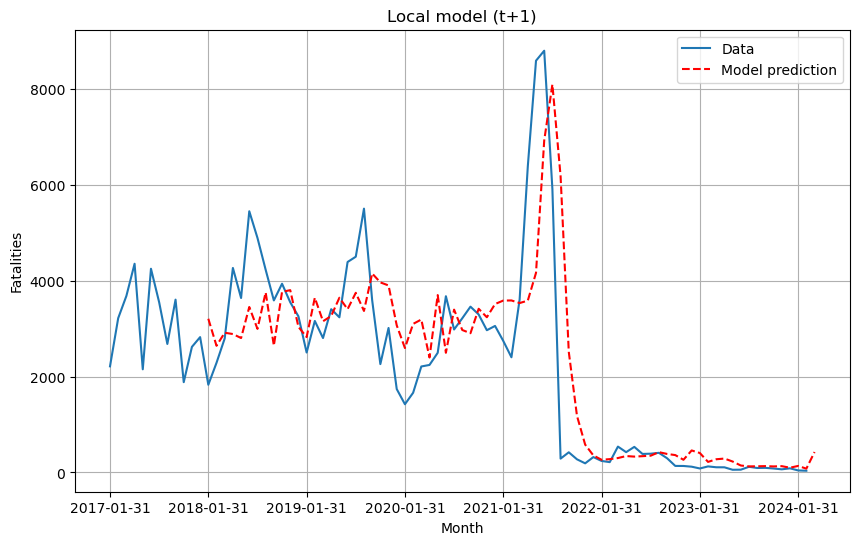

In [31]:
 # set column names
months_ahead = 1

for model in ["History", "History_local", "Local"]:
    plt.figure(figsize=(10, 6))
    plt.plot(saved_data["Month"], saved_data[f"fatalities t+{months_ahead}"], label='Data')
    plt.plot(saved_data["Month"], saved_data[f'{model} predicted change t+{months_ahead}'], label= "Model prediction", linestyle="--", color="red")
    plt.xlabel('Month')
    plt.ylabel("Fatalities")
    plt.title(f"{model} model (t+1)")
    plt.xticks(saved_data["Month"][::12])  # Ensure all months are shown on x-axis
    plt.legend()
    plt.grid(True)
    plt.savefig(f"Paper figures/Figure 4 {model}_model.png")
    plt.show()

### Figure 5

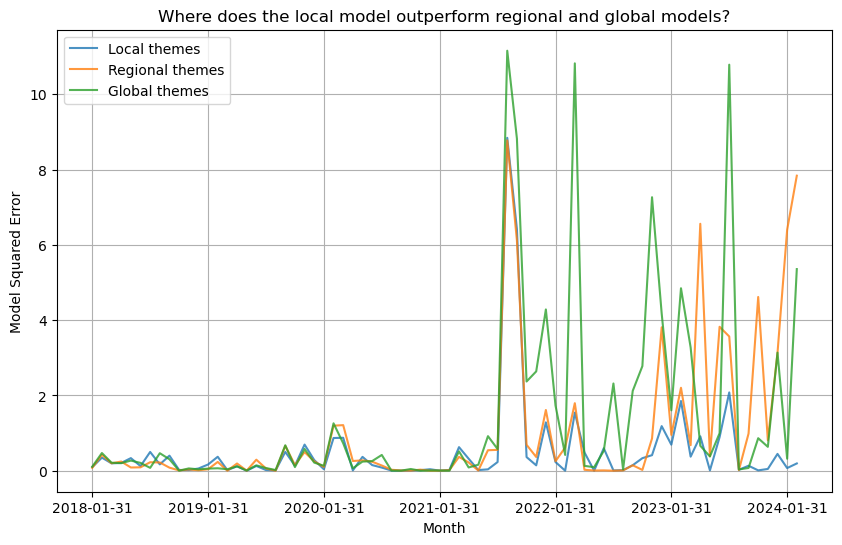

In [38]:
model_to_test = ["Local", "Regional", "Global"]

test_data = saved_data.copy()
for model in model_to_test:
    months_ahead = 1
    true_column = f"fatalities t+{months_ahead}"
    true_log_column = f"log change t+{months_ahead}"
    predicted_column = f'{model} predicted change t+{months_ahead}'
    predicted_log_column = f"{model} predicted log change t+{months_ahead}"
    error_column = f"error_squared {model}"

    test_data[error_column] = (test_data[true_log_column] - test_data[predicted_log_column])**2
    
x = test_data["Month"]
y1 = test_data[true_log_column]

plt.figure(figsize=(10, 6))
# plt.plot(x, y1, label='Data')
for model in model_to_test:
    y2 = test_data[f"error_squared {model}"]
    if model == "Regional":
        plt.plot(x[12:], y2[12:], label=f"Regional themes", alpha=0.8)
    if model == "Global":
        plt.plot(x[12:], y2[12:], label=f"Global themes", alpha=0.8)
    if model == "Local":
        plt.plot(x[12:], y2[12:], label=f"Local themes", alpha=0.8)
plt.xlabel('Month')
plt.ylabel("Model Squared Error")
plt.title("Where does the local model outperform regional and global models?")
plt.xticks(x[12::12])  # Ensure all months are shown on x-axis
plt.legend()
plt.grid(True)
plt.savefig("Paper figures/Figure 5.png")
plt.show()

### Figure 6:

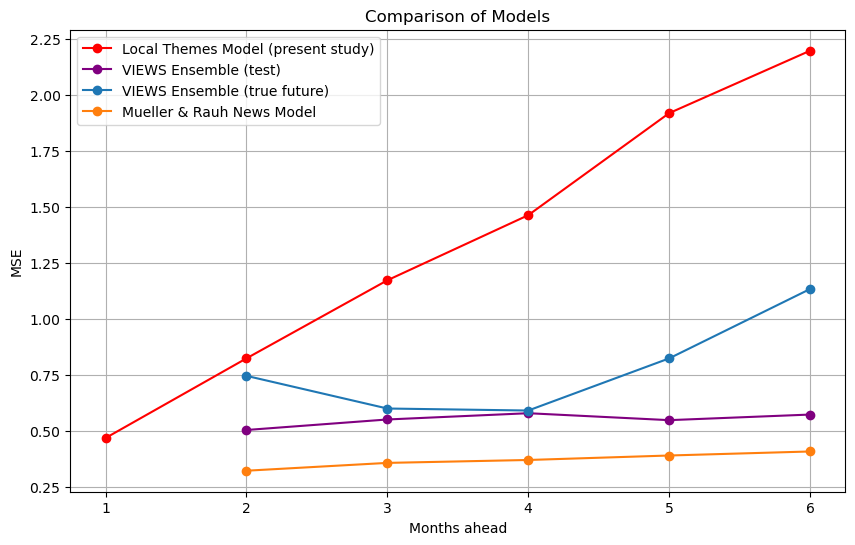

In [41]:
views_ensemble_model = [np.nan, 0.504, 0.551, 0.579, 0.548, 0.573]
views_true_future = [np.nan, 0.746, 0.600, 0.591, 0.824, 1.134]
mueller_rauh_model = [np.nan, 0.322, 0.357, 0.370, 0.390, 0.408] 
our_model_local = [0.468, 0.824, 1.173, 1.464, 1.920, 2.199]

x = np.arange(len(views_ensemble_model)) + 1

plt.figure(figsize=(10, 6))
plt.plot(x, our_model_local, marker='o', label='Local Themes Model (present study)', color="red")
plt.plot(x, views_ensemble_model, marker='o', label='VIEWS Ensemble (test)', color='purple')
plt.plot(x, views_true_future, marker='o', label='VIEWS Ensemble (true future)')
plt.plot(x, mueller_rauh_model, marker='o', label='Mueller & Rauh News Model')

plt.xlabel('Months ahead')
plt.ylabel('MSE')
plt.title('Comparison of Models')
plt.legend()
plt.grid(True)
plt.savefig("Paper figures/Figure 6.png")
plt.show()